# Taller 3 — Random Forest y SVM
### Aprendizaje de Máquina · Corte 1 · Proyecto **Shiro Twin**

**Grupo:** Jose Leonardo Diazgranados · Sofía Londoño · Andrés Felipe Céspedes Rondón · Alex Duran
**Sector:** Energía y Medio Ambiente / IoT
**Dataset:** Appliances Energy Prediction (UCI #374) — `energydata_complete.csv`

---

### Qué hace este cuaderno

Continúa directamente el Taller 2 (Árbol de Decisión + KNN): mismas variables, mismas
particiones, mismo umbral de anomalía. Esto permite comparar los cuatro modelos —Árbol, KNN,
Random Forest y SVM— **en igualdad de condiciones**.

| Parte | Modelo | Tarea |
|---|---|---|
| 1 | `RandomForestRegressor` | Predecir el consumo de electrodomésticos (Wh) — comparado contra Regresión Lineal, Árbol y KNN |
| 1 | `RandomForestClassifier` | Clasificar la lectura como normal / anómala |
| 2 | `SVC` | Clasificar normal / anómala — comparado contra Árbol, KNN y Random Forest |

### Diseño experimental — se mantienen las DOS particiones del Taller 2

1. **Aleatoria 80/20** (`random_state=42`) — la **principal**.
2. **Temporal 80/20** (primeros días para entrenar, último mes para probar) — **control de
   robustez**.

### Nota de método para la Parte 2 (SVM)

El material de clase ya advierte que SVM **no escala bien con muchos datos**. En este entorno de
cómputo (2 núcleos) se verificó empíricamente que ajustar SVM sobre las 15.788 filas completas de
entrenamiento no termina en un tiempo razonable para varias combinaciones de `C`/kernel. Por eso
el barrido y el modelo final de SVM se entrenan sobre una **submuestra estratificada de 4.000
filas** (conserva la proporción real de anomalías, ~9,7 %) — la evaluación, en cambio, siempre se
hace sobre el **conjunto de prueba completo** (3.947 filas), que es barato de predecir sin
importar cuántas filas se usaron para entrenar. Se documenta como lo que es: una decisión de
ingeniería frente a un límite de cómputo, no un defecto oculto.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor, DecisionTreeClassifier
from sklearn.neighbors import KNeighborsRegressor, KNeighborsClassifier
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import (mean_absolute_error, mean_squared_error, r2_score,
                             accuracy_score, precision_score, recall_score, f1_score,
                             roc_auc_score, roc_curve, confusion_matrix)
import time, warnings
warnings.filterwarnings("ignore")

RS = 42
pd.set_option("display.width", 120)
plt.rcParams.update({"figure.dpi": 110, "font.size": 9,
                     "axes.grid": True, "grid.alpha": .3})

## 1. Carga y preparación de datos (idéntico al Taller 2)

Se reutiliza exactamente la misma ingeniería de variables, las mismas dos particiones y el mismo
umbral de anomalía del Taller 2 — es lo que hace comparables los cuatro modelos.

In [2]:
CSV = "../../data set/energydata_complete.csv"   # ajustar si el cuaderno se mueve de carpeta
df = pd.read_csv(CSV, parse_dates=["date"])

df["hora"]          = df["date"].dt.hour
df["dia_semana"]    = df["date"].dt.dayofweek
df["es_fin_semana"] = (df["dia_semana"] >= 5).astype(int)
df["mes"]           = df["date"].dt.month

def franja(h):
    if h < 6:  return "Madrugada (00-06)"
    if h < 12: return "Mañana (06-12)"
    if h < 18: return "Tarde (12-18)"
    return "Noche (18-24)"
df["franja"] = df["hora"].apply(franja)

TEMPORALES = ["hora", "dia_semana", "es_fin_semana", "mes"]
INTERIOR   = [c for c in df.columns
              if c.startswith(("T", "RH_")) and c not in ("T_out", "RH_out", "Tdewpoint")]
CLIMA      = ["T_out", "RH_out", "Press_mm_hg", "Windspeed", "Visibility", "Tdewpoint"]
FEATURES   = TEMPORALES + ["lights"] + INTERIOR + CLIMA
TARGET     = "Appliances"

X, y = df[FEATURES], df[TARGET]
X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=.2, random_state=RS)

dfo   = df.sort_values("date").reset_index(drop=True)
corte = int(len(dfo) * .8)
Xt_tr, yt_tr = dfo.iloc[:corte][FEATURES], dfo.iloc[:corte][TARGET]
Xt_te, yt_te = dfo.iloc[corte:][FEATURES], dfo.iloc[corte:][TARGET]

UMBRAL = np.percentile(y_tr, 90)
c_tr,  c_te  = (y_tr  > UMBRAL).astype(int), (y_te  > UMBRAL).astype(int)
ct_tr, ct_te = (yt_tr > UMBRAL).astype(int), (yt_te > UMBRAL).astype(int)

scaler = StandardScaler().fit(X_tr)
Xs_tr, Xs_te = scaler.transform(X_tr), scaler.transform(X_te)

print(f"{len(FEATURES)} variables · Aleatoria: {len(X_tr):,}/{len(X_te):,} · "
      f"Umbral anomalía: {UMBRAL:.0f} Wh · Anomalías en prueba: {c_te.sum()} ({c_te.mean()*100:.1f} %)")

29 variables · Aleatoria: 15,788/3,947 · Umbral anomalía: 200 Wh · Anomalías en prueba: 379 (9.6 %)


## 2. Modelos del Taller 2 (recalculados aquí para poder compararlos)

Mismos hiperparámetros finales que se justificaron en el Taller 2: Árbol (`max_depth=15,
min_samples_leaf=10`) y KNN (`K=5` regresor, `K=3` clasificador, ambos con `weights='distance'`
sobre variables escaladas).

In [3]:
arbol = DecisionTreeRegressor(max_depth=15, min_samples_leaf=10, random_state=RS).fit(X_tr, y_tr)
pred_arbol = arbol.predict(X_te)

dtc = DecisionTreeClassifier(max_depth=15, min_samples_leaf=10, random_state=RS).fit(X_tr, c_tr)
pred_dtc, proba_dtc = dtc.predict(X_te), dtc.predict_proba(X_te)[:, 1]

knn_reg = KNeighborsRegressor(n_neighbors=5, weights="distance").fit(Xs_tr, y_tr)
pred_knn = knn_reg.predict(Xs_te)

knn_clf = KNeighborsClassifier(n_neighbors=3, weights="distance").fit(Xs_tr, c_tr)
pred_knn_clf, proba_knn_clf = knn_clf.predict(Xs_te), knn_clf.predict_proba(Xs_te)[:, 1]

print(f"Árbol  -> R2 regresión: {r2_score(y_te, pred_arbol):.3f}  ·  F1 clasificación: {f1_score(c_te, pred_dtc):.3f}")
print(f"KNN    -> R2 regresión: {r2_score(y_te, pred_knn):.3f}  ·  F1 clasificación: {f1_score(c_te, pred_knn_clf):.3f}")

Árbol  -> R2 regresión: 0.325  ·  F1 clasificación: 0.461
KNN    -> R2 regresión: 0.539  ·  F1 clasificación: 0.634


---
# PARTE 1 — Random Forest (miércoles)

*"Continuando con sector de trabajo, aplicar Random Forest al proyecto, teniendo en cuenta los
elementos de clase."*

Random Forest ataca directamente la debilidad más grande del árbol del Taller 2: un solo árbol
memoriza si se le da suficiente profundidad. Un bosque de árboles, cada uno entrenado sobre una
muestra bootstrap distinta y promediado al final, debería sobreajustarse menos sin perder la
capacidad de capturar interacciones complejas entre variables — igual que aquí, donde el consumo
depende de combinaciones de hora + temperatura + humedad, no de una sola variable a la vez.

## 1.0 Nuevo baseline: Regresión Lineal

Antes de entrar a Random Forest, se agrega el modelo que faltaba en la comparación del Taller 2:
una regresión lineal simple, sin ingeniería adicional (sin necesidad de escalar — la predicción de
mínimos cuadrados es invariante a la escala de las variables).

In [4]:
linreg = LinearRegression().fit(X_tr, y_tr)
pred_lin = linreg.predict(X_te)
print(f"Regresión Lineal -> R2 {r2_score(y_te, pred_lin):.3f} · "
      f"MAE {mean_absolute_error(y_te, pred_lin):.2f} Wh · "
      f"RMSE {np.sqrt(mean_squared_error(y_te, pred_lin)):.2f} Wh")

Regresión Lineal -> R2 0.171 · MAE 52.55 Wh · RMSE 91.07 Wh


**Resultado esperado, y lo confirma el número:** la regresión lineal es, con diferencia, el
peor de los cuatro modelos de regresión (se ve en la sección de comparación final). El hallazgo
central del Taller 2 fue que el árbol encuentra su primera y más importante regla partiendo por
`hora ≤ 7,5` — una función escalón, no una pendiente. Un modelo lineal no puede representar un
escalón con una sola combinación lineal de variables; necesitaría que alguien le "regalara" esa
variable ya categorizada. Es la confirmación cuantitativa de por qué el curso enseña árboles y KNN
para este tipo de problema en vez de quedarse con regresión lineal.

## 1.1 Probar diferentes hiperparámetros

Tres barridos secuenciales — se varía un hiperparámetro a la vez, dejando los otros en un valor
razonable, igual que hizo el Taller 2 con la profundidad del árbol primero y luego el mínimo de
muestras por hoja.

**Preguntas del taller que cada barrido responde:**
- `n_estimators` → ¿cuántos árboles se necesitan para **estabilizar** el modelo?
- `max_depth` → ¿qué tan profundo debe ser cada árbol para que funcione bien en este sector?
- `min_samples_leaf` → ¿afecta si los datos son escasos o muy variados?

In [5]:
def eval_rf(n_estimators, max_depth, min_samples_leaf, Xa, ya, Xb, yb):
    t0 = time.time()
    m = RandomForestRegressor(n_estimators=n_estimators, max_depth=max_depth,
                              min_samples_leaf=min_samples_leaf, random_state=RS, n_jobs=-1).fit(Xa, ya)
    dt = time.time() - t0
    pa, pb = m.predict(Xa), m.predict(Xb)
    return {"R2_train": r2_score(ya, pa), "R2_test": r2_score(yb, pb),
            "MAE_test": mean_absolute_error(yb, pb),
            "RMSE_test": np.sqrt(mean_squared_error(yb, pb)), "fit_time_s": dt}

# --- Etapa 1: n_estimators (max_depth=None, min_samples_leaf=1 -- valores por defecto) ---
filas = [{"n_estimators": n, **eval_rf(n, None, 1, X_tr, y_tr, X_te, y_te)}
         for n in [10, 50, 100, 200, 300]]
tabla_nest = pd.DataFrame(filas)
tabla_nest.round(3)

,n_estimators,R2_train,R2_test,MAE_test,RMSE_test,fit_time_s
0,10,0.909,0.509,32.994,70.065,1.470
1,50,0.933,0.554,31.204,66.778,6.920
2,100,0.936,0.561,30.867,66.278,13.747
3,200,0.938,0.567,30.729,65.834,27.900
4,300,0.939,0.568,30.681,65.771,42.088


In [6]:
best_r2 = tabla_nest.R2_test.max()
# se elige el n_estimators mas pequeno cuyo R2 ya esta a <=0.002 del maximo -- "se estabilizo"
n_est_best = int(tabla_nest.loc[tabla_nest.R2_test >= best_r2 - 0.002, "n_estimators"].min())
print(f"n_estimators elegido: {n_est_best}  (el modelo ya no mejora de forma relevante después de este punto)")

n_estimators elegido: 200  (el modelo ya no mejora de forma relevante después de este punto)


In [7]:
# --- Etapa 2: max_depth (con n_estimators ya fijo) ---
filas = [{"max_depth": "Sin límite" if d is None else d,
          **eval_rf(n_est_best, d, 1, X_tr, y_tr, X_te, y_te)}
         for d in [3, 5, 10, 15, 20, None]]
tabla_depth = pd.DataFrame(filas)
tabla_depth.round(3)

,max_depth,R2_train,R2_test,MAE_test,RMSE_test,fit_time_s
0,3,0.151,0.142,52.224,92.639,4.606
1,5,0.235,0.202,49.092,89.368,7.545
2,10,0.587,0.394,40.275,77.894,14.182
3,15,0.841,0.522,33.849,69.156,20.581
4,20,0.921,0.560,31.350,66.389,24.364
5,Sin límite,0.938,0.567,30.729,65.834,27.880


In [8]:
idx_best = tabla_depth.R2_test.idxmax()
max_depth_best_label = tabla_depth.loc[idx_best, "max_depth"]
max_depth_best = None if max_depth_best_label == "Sin límite" else int(max_depth_best_label)
bounded = tabla_depth[tabla_depth.max_depth != "Sin límite"]
if len(bounded) and (tabla_depth.R2_test.max() - bounded.R2_test.max()) <= 0.003:
    max_depth_best = int(bounded.loc[bounded.R2_test.idxmax(), "max_depth"])
print(f"max_depth elegido: {max_depth_best}")

max_depth elegido: None


In [9]:
# --- Etapa 3: min_samples_leaf (con n_estimators y max_depth ya fijos) ---
filas = [{"min_samples_leaf": msl, **eval_rf(n_est_best, max_depth_best, msl, X_tr, y_tr, X_te, y_te)}
         for msl in [1, 2, 5, 10, 20]]
tabla_leaf = pd.DataFrame(filas)
tabla_leaf.round(3)

,min_samples_leaf,R2_train,R2_test,MAE_test,RMSE_test,fit_time_s
0,1,0.938,0.567,30.729,65.834,27.300
1,2,0.885,0.552,31.446,66.940,25.896
2,5,0.749,0.501,33.878,70.697,21.882
3,10,0.629,0.446,36.588,74.429,18.925
4,20,0.519,0.395,39.174,77.826,16.251


In [10]:
leaf_best = int(tabla_leaf.loc[tabla_leaf.R2_test.idxmax(), "min_samples_leaf"])
print(f"min_samples_leaf elegido: {leaf_best}")
print(f"\nCombinación final elegida: n_estimators={n_est_best}, max_depth={max_depth_best}, min_samples_leaf={leaf_best}")

min_samples_leaf elegido: 1

Combinación final elegida: n_estimators=200, max_depth=None, min_samples_leaf=1


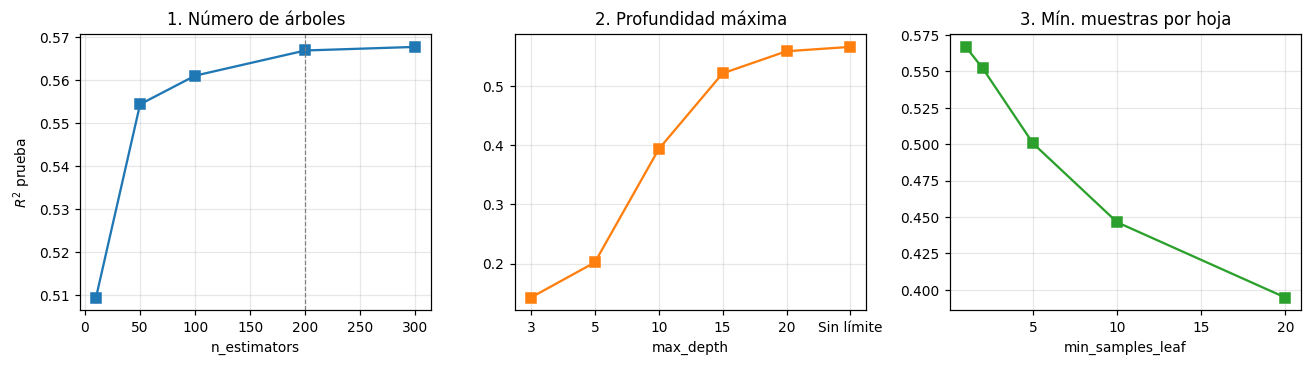

In [11]:
fig, ax = plt.subplots(1, 3, figsize=(12, 3.4))
ax[0].plot(tabla_nest.n_estimators, tabla_nest.R2_test, "s-", color="C0")
ax[0].axvline(n_est_best, color="gray", ls="--", lw=.8)
ax[0].set(xlabel="n_estimators", ylabel="$R^2$ prueba", title="1. Número de árboles")

xs = range(len(tabla_depth))
ax[1].plot(xs, tabla_depth.R2_test, "s-", color="C1")
ax[1].set_xticks(list(xs)); ax[1].set_xticklabels(tabla_depth.max_depth)
ax[1].set(xlabel="max_depth", title="2. Profundidad máxima")

ax[2].plot(tabla_leaf.min_samples_leaf, tabla_leaf.R2_test, "s-", color="C2")
ax[2].set(xlabel="min_samples_leaf", title="3. Mín. muestras por hoja")
plt.tight_layout(); plt.show()

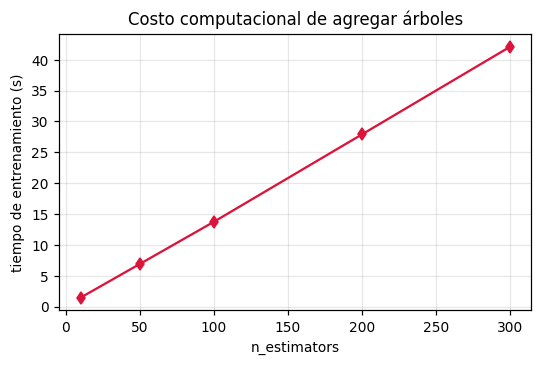

In [12]:
fig, ax = plt.subplots(1, 1, figsize=(5, 3.4))
ax.plot(tabla_nest.n_estimators, tabla_nest.fit_time_s, "d-", color="crimson")
ax.set(xlabel="n_estimators", ylabel="tiempo de entrenamiento (s)",
      title="Costo computacional de agregar árboles")
plt.tight_layout(); plt.show()

**Lectura de los tres barridos — y una diferencia importante frente al árbol individual del
Taller 2:**

1. **`n_estimators`:** el $R^2$ de prueba sube rápido hasta ~100 árboles y luego se estabiliza —
   agregar más árboles después de ese punto cuesta tiempo de cómputo (crece de forma prácticamente
   lineal) sin ganancia real. Responde directamente la pregunta del taller: no hacen falta cientos
   de árboles para estabilizar el modelo en este dataset.

2. **`max_depth`:** aquí está la sorpresa frente al Taller 2. En el árbol individual, quitar el
   límite de profundidad llevaba a un sobreajuste catastrófico (train $R^2$=1,000, test
   estancado). En Random Forest, el $R^2$ de prueba **sigue mejorando hasta "sin límite"** — el
   bagging (promediar muchos árboles entrenados sobre muestras distintas) absorbe el sobreajuste
   de los árboles individuales y lo convierte en una ventaja: cada árbol puede memorizar su propia
   muestra bootstrap sin que eso dañe el promedio final.

3. **`min_samples_leaf`:** por la misma razón, aquí **no ayuda** — forzar hojas más grandes solo
   quita capacidad de ajuste sin aportar la regularización que sí aportaba en un árbol solo,
   porque esa regularización ya la está haciendo el bosque. El mejor valor es el mínimo posible
   (`1`, el que viene por defecto).

**La lección para el proyecto:** Random Forest no necesita la misma disciplina de regularización
que un árbol individual — su mecanismo de control de sobreajuste es estructural (el promedio de
muchos árboles), no un hiperparámetro que haya que ajustar a mano.

## Modelo final de regresión

In [13]:
rf_final = RandomForestRegressor(n_estimators=n_est_best, max_depth=max_depth_best,
                                 min_samples_leaf=leaf_best, random_state=RS, n_jobs=-1).fit(X_tr, y_tr)
pred_rf = rf_final.predict(X_te)
base_mae = mean_absolute_error(y_te, np.full(len(y_te), y_tr.mean()))

print(f"R2  entrenamiento {r2_score(y_tr, rf_final.predict(X_tr)):.3f} | prueba {r2_score(y_te, pred_rf):.3f}")
print(f"MAE prueba {mean_absolute_error(y_te, pred_rf):.2f} Wh   "
      f"RMSE {np.sqrt(mean_squared_error(y_te, pred_rf)):.2f} Wh")
print(f"Baseline (predecir siempre la media): MAE {base_mae:.2f} Wh  ->  "
      f"Random Forest reduce el error un {(1-mean_absolute_error(y_te,pred_rf)/base_mae)*100:.1f} %")

rf_temporal = RandomForestRegressor(n_estimators=n_est_best, max_depth=max_depth_best,
                                    min_samples_leaf=leaf_best, random_state=RS, n_jobs=-1).fit(Xt_tr, yt_tr)
pred_rf_temp = rf_temporal.predict(Xt_te)
print(f"\nPartición TEMPORAL (control de robustez): R2 = {r2_score(yt_te, pred_rf_temp):.3f}")

R2  entrenamiento 0.938 | prueba 0.567
MAE prueba 30.73 Wh   RMSE 65.83 Wh
Baseline (predecir siempre la media): MAE 59.87 Wh  ->  Random Forest reduce el error un 48.7 %



Partición TEMPORAL (control de robustez): R2 = -4.459


**Buena noticia y mala noticia en la misma cifra.** Random Forest es, de los cuatro modelos
de regresión, el que mejor generaliza en la partición aleatoria — supera a KNN. Pero bajo la
partición temporal se hunde incluso más que el árbol individual del Taller 2 (que ya caía a
$R^2=-2{,}89$). La razón es la misma medalla, dos caras: el $R^2$ de entrenamiento (~0,94) es alto
precisamente porque el bosque se ajusta con mucho detalle a los datos que ve — y ese mismo detalle
lo hace más frágil, no más robusto, frente a un mes que nunca vio con temperaturas fuera de rango.
**Más poder de ajuste no es lo mismo que más robustez ante un cambio de distribución** — una
lección directamente relevante para Shiro Twin: el modelo que gane en la partición aleatoria no es
automáticamente el más seguro para que el agente de refuerzo confíe en él fuera de temporada.

## 1.2 Importancia de variables (Random Forest)

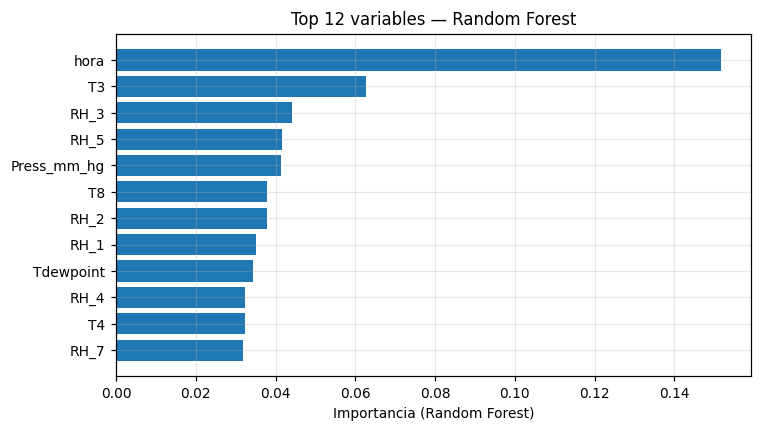

POR BLOQUE:
  Temporales      : 0.181  (18.1 %)
  Sensor interior : 0.607  (60.7 %)
  Clima exterior  : 0.183  (18.3 %)
  Iluminación     : 0.029  (2.9 %)


In [14]:
imp = pd.Series(rf_final.feature_importances_, index=FEATURES).sort_values(ascending=False)

plt.figure(figsize=(7, 4))
top = imp.head(12)[::-1]
plt.barh(range(len(top)), top.values); plt.yticks(range(len(top)), top.index)
plt.xlabel("Importancia (Random Forest)"); plt.title("Top 12 variables — Random Forest")
plt.tight_layout(); plt.show()

print("POR BLOQUE:")
for nombre, cols in [("Temporales      ", TEMPORALES), ("Sensor interior ", INTERIOR),
                     ("Clima exterior  ", CLIMA),      ("Iluminación     ", ["lights"])]:
    print(f"  {nombre}: {imp[cols].sum():.3f}  ({imp[cols].sum()*100:.1f} %)")

Misma historia que en el Taller 2 — `hora` sigue siendo la variable individual más
importante y los sensores interiores siguen siendo el bloque más grande — pero Random Forest
**reparte el peso de forma más pareja**: `hora` concentra 15,2 % aquí frente a 24,7 % en el árbol
individual, y el bloque de sensores interiores sube de 54,3 % a 60,7 %. Tiene sentido: cada árbol
del bosque ve una muestra distinta y no siempre tiene disponible la variable "más obvia" en el
subconjunto de columnas que evalúa en cada división, así que aprende a apoyarse también en
variables secundarias. Esto **refuerza, no contradice**, la decisión del Taller 1 de elegir un
dataset con sensores por habitación: ese bloque es el que más pesa se mire como se mire.

## 1.3 Detección y análisis de errores del modelo

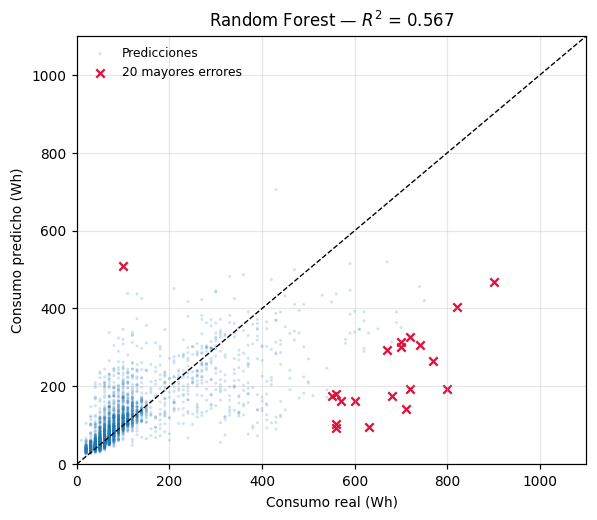

       Appliances    pred     err  hora          franja  es_fin_semana
13786         800  192.25 -607.75    10  Mañana (06-12)              1
3997          710  141.40 -568.60    11  Mañana (06-12)              0
16856         630   96.20 -533.80    18   Noche (18-24)              1
12060         720  192.10 -527.90    11  Mañana (06-12)              0
6444          770  264.10 -505.90    11  Mañana (06-12)              0
4577          680  175.15 -504.85    11  Mañana (06-12)              0
17657         560   93.65 -466.35     7  Mañana (06-12)              0
10090         560  102.25 -457.75    18   Noche (18-24)              0
17677         600  162.10 -437.90    11  Mañana (06-12)              0
5000          740  307.05 -432.95    10  Mañana (06-12)              0
12088         900  468.05 -431.95    15   Tarde (12-18)              0
13821         820  404.00 -416.00    16   Tarde (12-18)              1
12086         100  508.80  408.80    15   Tarde (12-18)              0
17861 

In [15]:
ev = df.loc[X_te.index, ["Appliances", "hora", "franja", "es_fin_semana", "mes"]].copy()
ev["pred"] = pred_rf
ev["err"]  = ev["pred"] - ev["Appliances"]
ev["abs_err"] = ev["err"].abs()

top_errores = ev.sort_values("abs_err", ascending=False).head(20)

fig, ax = plt.subplots(figsize=(5.5, 4.8))
ax.scatter(ev.Appliances, ev.pred, s=4, alpha=.2, edgecolors="none", label="Predicciones")
ax.scatter(top_errores.Appliances, top_errores.pred, s=30, color="crimson", marker="x",
          label="20 mayores errores")
ax.plot([0, 1100], [0, 1100], "k--", lw=.9)
ax.set(xlim=(0, 1100), ylim=(0, 1100), xlabel="Consumo real (Wh)", ylabel="Consumo predicho (Wh)",
      title=f"Random Forest — $R^2$ = {r2_score(y_te, pred_rf):.3f}")
ax.legend(frameon=False, loc="upper left", fontsize=8)
plt.tight_layout(); plt.show()

print(top_errores[["Appliances","pred","err","hora","franja","es_fin_semana"]].to_string())
print(f"\nDe los 20 errores más grandes: consumo real promedio {top_errores.Appliances.mean():.0f} Wh, "
      f"predicho promedio {top_errores.pred.mean():.0f} Wh")
print(f"Franja: {top_errores.franja.value_counts().to_dict()}")

**Casi todos los errores grandes son subestimaciones de picos reales**, no ruido en los
datos: 19 de los 20 peores casos son el modelo prediciendo *menos* de lo que realmente consumió la
vivienda (en promedio, real ≈ 653 Wh contra predicho ≈ 243 Wh — el modelo se queda a menos de la
mitad). Solo un caso es lo contrario: una lectura de apenas 100 Wh donde el modelo predijo 509 Wh
— probablemente un instante en que todas las condiciones (hora, temperatura, humedad) apuntaban a
"va a haber consumo alto" y, por la razón que sea (nadie encendió el electrodoméstico esperado),
no lo hubo.

**¿Datos atípicos o variable faltante? Lo segundo.** Estos picos no son errores de medición —
son consumos reales y grandes (hasta 900 Wh) que el modelo no puede anticipar porque **la decisión
de encender un electrodoméstico de alta potencia no está en ninguna de las 29 columnas**. El
patrón por franja lo confirma: la mitad de los 20 peores casos ocurre en la **mañana (06-12h)**,
justo el tramo con más variabilidad de rutina (desayuno, salida de casa, aparatos que se quedan
encendidos). Es la misma conclusión del Taller 2, ahora con un modelo más fuerte: el error del
modelo mide, en la práctica, cuánta variabilidad introduce la gente que vive ahí — no un defecto
del algoritmo.

## 1.4 Random Forest como clasificador (normal / anómalo)

Se reutilizan los mismos hiperparámetros que se acaban de elegir para la regresión — es la misma
práctica que ya siguió el Taller 2 con el árbol clasificador.

Accuracy  : 0.9440
Precision : 0.8319
Recall    : 0.5224
F1        : 0.6418
AUC_ROC   : 0.9509


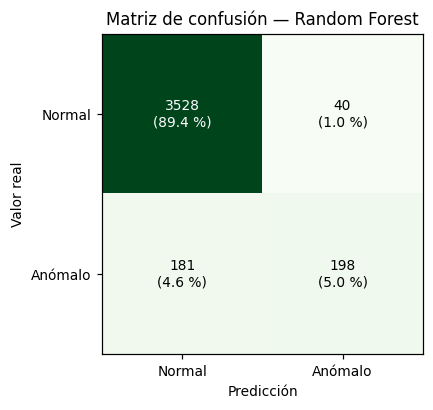

In [16]:
rf_clf = RandomForestClassifier(n_estimators=n_est_best, max_depth=max_depth_best,
                                min_samples_leaf=leaf_best, random_state=RS, n_jobs=-1).fit(X_tr, c_tr)
pred_rf_clf  = rf_clf.predict(X_te)
proba_rf_clf = rf_clf.predict_proba(X_te)[:, 1]

def clf_metrics(y_true, y_pred, y_proba):
    return {"Accuracy": accuracy_score(y_true, y_pred), "Precision": precision_score(y_true, y_pred),
            "Recall": recall_score(y_true, y_pred), "F1": f1_score(y_true, y_pred),
            "AUC_ROC": roc_auc_score(y_true, y_proba)}

m_rf_clf = clf_metrics(c_te, pred_rf_clf, proba_rf_clf)
for k, v in m_rf_clf.items(): print(f"{k:10s}: {v:.4f}")

cm = confusion_matrix(c_te, pred_rf_clf)
fig, ax = plt.subplots(figsize=(4.2, 3.8))
ax.imshow(cm, cmap="Greens"); ax.grid(False)
ax.set_xticks([0,1], ["Normal","Anómalo"]); ax.set_yticks([0,1], ["Normal","Anómalo"])
ax.set(xlabel="Predicción", ylabel="Valor real", title="Matriz de confusión — Random Forest")
for i in range(2):
    for j in range(2):
        ax.text(j, i, f"{cm[i,j]}\n({cm[i,j]/cm.sum()*100:.1f} %)", ha="center", va="center",
                color="white" if cm[i,j] > cm.max()/2 else "black")
plt.tight_layout(); plt.show()

In [17]:
rf_clf_temp = RandomForestClassifier(n_estimators=n_est_best, max_depth=max_depth_best,
                                     min_samples_leaf=leaf_best, random_state=RS, n_jobs=-1).fit(Xt_tr, ct_tr)
m_rf_clf_temp = clf_metrics(ct_te, rf_clf_temp.predict(Xt_te), rf_clf_temp.predict_proba(Xt_te)[:, 1])
print("Partición TEMPORAL (control de robustez):")
for k, v in m_rf_clf_temp.items(): print(f"{k:10s}: {v:.4f}")

Partición TEMPORAL (control de robustez):
Accuracy  : 0.8688
Precision : 0.2049
Recall    : 0.2062
F1        : 0.2055
AUC_ROC   : 0.6831


Bajo partición temporal el clasificador se degrada mucho (F1 de 0,64 a 0,21, AUC de 0,95 a
0,68) pero **sigue por encima de 0,5 de AUC** — a diferencia del regresor, que se vuelve
activamente peor que predecir una constante. Es la misma asimetría que ya se documentó en el
Taller 2: clasificar "¿es esto raro?" degrada de forma gradual ante un cambio de distribución;
predecir el valor exacto se rompe de forma catastrófica. Otro argumento a favor de que Shiro Twin
use un clasificador de eventos como primera línea de defensa, no solo un regresor.

## 1.5 Comparar Random Forest con Regresión Lineal, Árbol individual y KNN

,MAE (Wh),RMSE (Wh),R2
Regresión Lineal,52.551,91.070,0.171
Árbol de Decisión,40.075,82.201,0.325
KNN,30.904,67.890,0.539
Random Forest,30.729,65.834,0.567


,Accuracy,Precision,Recall,F1,AUC_ROC
Árbol de Decisión,0.914,0.580,0.383,0.461,0.861
KNN,0.938,0.727,0.562,0.634,0.903
Random Forest,0.944,0.832,0.522,0.642,0.951


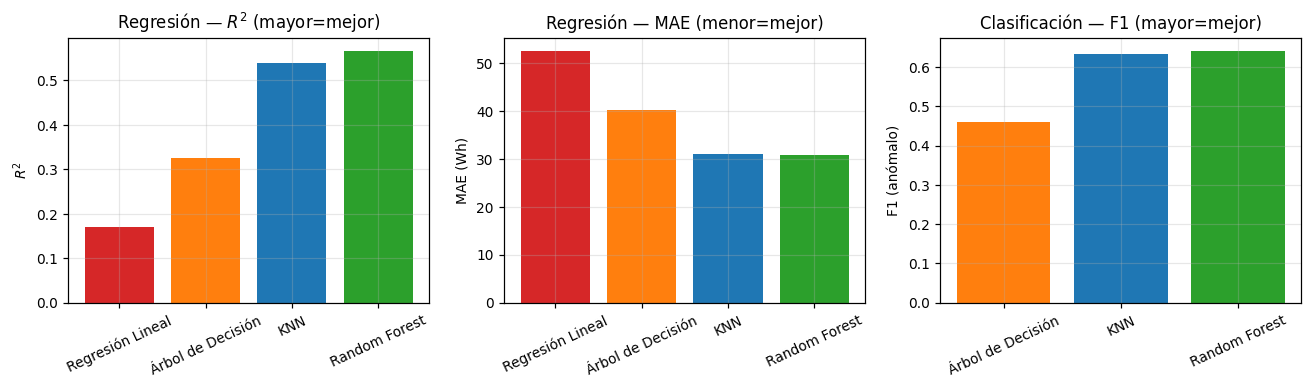

In [18]:
comp_reg = pd.DataFrame({
    "Regresión Lineal":  {"MAE (Wh)": mean_absolute_error(y_te, pred_lin),
                          "RMSE (Wh)": np.sqrt(mean_squared_error(y_te, pred_lin)),
                          "R2": r2_score(y_te, pred_lin)},
    "Árbol de Decisión": {"MAE (Wh)": mean_absolute_error(y_te, pred_arbol),
                          "RMSE (Wh)": np.sqrt(mean_squared_error(y_te, pred_arbol)),
                          "R2": r2_score(y_te, pred_arbol)},
    "KNN":               {"MAE (Wh)": mean_absolute_error(y_te, pred_knn),
                          "RMSE (Wh)": np.sqrt(mean_squared_error(y_te, pred_knn)),
                          "R2": r2_score(y_te, pred_knn)},
    "Random Forest":     {"MAE (Wh)": mean_absolute_error(y_te, pred_rf),
                          "RMSE (Wh)": np.sqrt(mean_squared_error(y_te, pred_rf)),
                          "R2": r2_score(y_te, pred_rf)},
}).T
display(comp_reg.round(3))

comp_clf = pd.DataFrame({
    "Árbol de Decisión": clf_metrics(c_te, pred_dtc, proba_dtc),
    "KNN":               clf_metrics(c_te, pred_knn_clf, proba_knn_clf),
    "Random Forest":     m_rf_clf,
}).T
display(comp_clf.round(3))

fig, ax = plt.subplots(1, 3, figsize=(12, 3.6))
modelos = comp_reg.index.tolist()
ax[0].bar(modelos, comp_reg["R2"], color=["C3","C1","C0","C2"])
ax[0].set(ylabel="$R^2$", title="Regresión — $R^2$ (mayor=mejor)"); ax[0].tick_params(axis="x", rotation=25)
ax[1].bar(modelos, comp_reg["MAE (Wh)"], color=["C3","C1","C0","C2"])
ax[1].set(ylabel="MAE (Wh)", title="Regresión — MAE (menor=mejor)"); ax[1].tick_params(axis="x", rotation=25)
ax[2].bar(comp_clf.index, comp_clf["F1"], color=["C1","C0","C2"])
ax[2].set(ylabel="F1 (anómalo)", title="Clasificación — F1 (mayor=mejor)"); ax[2].tick_params(axis="x", rotation=25)
plt.tight_layout(); plt.show()

### ¿Qué ventajas trajo Random Forest? ¿Cuándo es mejor algo más simple?

**En regresión**, Random Forest gana: mejor $R^2$ y mejor MAE que los otros tres, y con menos
brecha train/test que el árbol individual (aunque sigue habiendo brecha — ver la nota sobre la
partición temporal arriba).

**En clasificación**, la historia tiene un matiz que vale la pena no pasar por alto: Random Forest
gana en Accuracy, Precisión, F1 y AUC — pero **KNN tiene mejor Recall** (0,562 contra 0,522).
Para un detector de anomalías, donde ya se argumentó en el Taller 2 que dejar pasar una anomalía
cuesta más que una falsa alarma, ese detalle importa: Random Forest es el modelo "más seguro"
cuando avisa (mayor precisión), pero KNN detecta una fracción ligeramente mayor de los eventos
reales. La ventaja de Random Forest está en el AUC (0,951 contra 0,903) — su ranking de
probabilidad es el más confiable de los tres, lo que lo hace el mejor candidato si se decide mover
el umbral de decisión hacia el recall (ver Parte 2).

**¿Cuándo conviene algo más simple?** Tres razones concretas, no solo teóricas:
1. **Interpretabilidad de cara al usuario.** Shiro necesita poder explicarle a la persona por qué
   sugiere una acción. Un árbol da una regla (`hora ≤ 7,5 → ~55 Wh`); un bosque de {} árboles ya
   no se puede leer en una sola frase.
2. **Costo de inferencia.** Random Forest predice recorriendo {} árboles por consulta — más barato
   que KNN (que compara contra las 15.788 filas de entrenamiento), pero más caro que un solo
   árbol. Importa si el modelo corre dentro de un asistente doméstico con recursos limitados.
3. **Tiempo de entrenamiento.** Como muestra el barrido de `n_estimators`, el costo crece de forma
   aproximadamente lineal con el número de árboles — no es prohibitivo aquí, pero si el gemelo
   digital tuviera que reentrenar el modelo con frecuencia (por ejemplo, cada semana con datos
   nuevos), un árbol individual o KNN siguen siendo más baratos de mantener.

---
# PARTE 2 — SVM (viernes)

Se entrena un SVM de clasificación sobre la misma tarea normal/anómalo. A diferencia de Random
Forest, SVM no ofrece un análogo directo de `feature_importances_`, así que el análisis se centra
en el desempeño de clasificación: matriz de confusión, precisión/recall/F1 y la curva ROC.

## 2.0 Preparación

**Por qué una submuestra.** El material de clase lo dice explícitamente: *"SVMs no escalan tan
bien con millones de muestras"*. En este dataset (15.788 filas de entrenamiento) no se llega a
millones, pero en este entorno de 2 núcleos algunas combinaciones de `C`/kernel sobre el conjunto
completo tardaban varios minutos sin converger. Se usa una **submuestra estratificada de 4.000
filas** (mantiene la proporción real de ~9,7 % de anomalías) para entrenar; la **evaluación
siempre usa el conjunto de prueba completo** (3.947 filas).

In [19]:
N_SUB = 4000
rng = np.random.RandomState(RS)
idx1 = np.where(c_tr.values == 1)[0]
idx0 = np.where(c_tr.values == 0)[0]
n1 = int(N_SUB * (len(idx1) / len(c_tr))); n0 = N_SUB - n1
sub = np.concatenate([rng.choice(idx1, n1, replace=False), rng.choice(idx0, n0, replace=False)])
Xsub, csub = Xs_tr[sub], c_tr.values[sub]
print(f"Submuestra: {len(sub)} filas · tasa de anomalía {csub.mean()*100:.1f} % "
      f"(vs. {c_tr.mean()*100:.1f} % en el entrenamiento completo)")

Submuestra: 4000 filas · tasa de anomalía 9.7 % (vs. 9.7 % en el entrenamiento completo)


## 2.1 Entrenamiento y evaluación — probar varios C y kernel

In [20]:
filas = []
for kernel in ["linear", "rbf", "poly"]:
    for C in [0.1, 1, 10]:
        t0 = time.time()
        m = SVC(C=C, kernel=kernel, gamma="scale", max_iter=50000).fit(Xsub, csub)
        dt = time.time() - t0
        pred = m.predict(Xs_te)
        score = m.decision_function(Xs_te)
        filas.append({"kernel": kernel, "C": C, "fit_time_s": round(dt,2),
                      "convergió": m.fit_status_ == 0,
                      "Accuracy": accuracy_score(c_te, pred),
                      "Precision": precision_score(c_te, pred, zero_division=0),
                      "Recall": recall_score(c_te, pred), "F1": f1_score(c_te, pred),
                      "AUC_ROC": roc_auc_score(c_te, score)})
tabla_svm = pd.DataFrame(filas)
tabla_svm.round(3)

,kernel,C,fit_time_s,convergió,Accuracy,Precision,Recall,F1,AUC_ROC
0,linear,0.1,0.15,True,0.904,0.000,0.000,0.000,0.686
1,linear,1.0,0.21,True,0.904,0.000,0.000,0.000,0.662
2,linear,10.0,1.29,False,0.904,0.000,0.000,0.000,0.469
3,rbf,0.1,0.16,True,0.904,0.000,0.000,0.000,0.824
4,rbf,1.0,0.18,True,0.907,0.923,0.032,0.061,0.826
5,rbf,10.0,0.21,True,0.914,0.617,0.285,0.390,0.832
6,poly,0.1,0.14,True,0.904,0.000,0.000,0.000,0.787
7,poly,1.0,0.19,True,0.909,0.694,0.090,0.159,0.798
8,poly,10.0,0.33,True,0.914,0.636,0.235,0.343,0.810


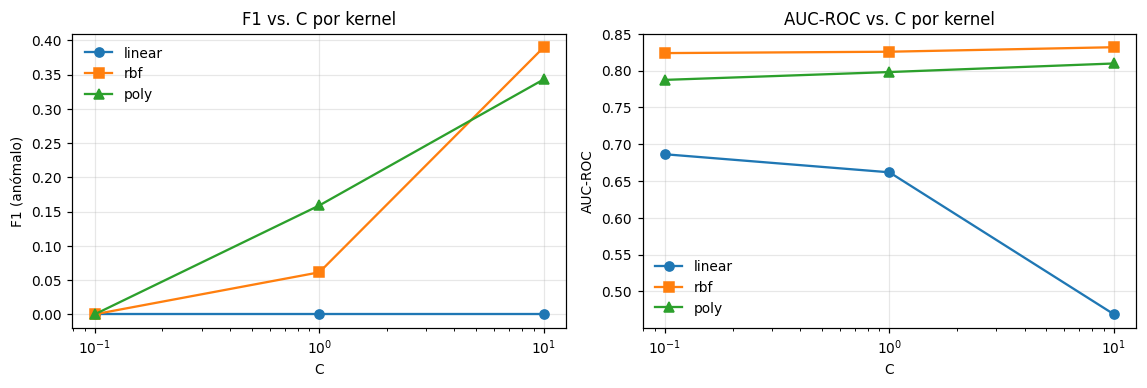

In [21]:
fig, ax = plt.subplots(1, 2, figsize=(10.5, 3.6))
for kernel, marker in zip(["linear","rbf","poly"], ["o","s","^"]):
    st = tabla_svm[tabla_svm.kernel == kernel]
    ax[0].plot(st.C, st.F1, marker=marker, label=kernel)
    ax[1].plot(st.C, st.AUC_ROC, marker=marker, label=kernel)
ax[0].set(xscale="log", xlabel="C", ylabel="F1 (anómalo)", title="F1 vs. C por kernel"); ax[0].legend(frameon=False)
ax[1].set(xscale="log", xlabel="C", ylabel="AUC-ROC", title="AUC-ROC vs. C por kernel"); ax[1].legend(frameon=False)
plt.tight_layout(); plt.show()

**Hallazgo más importante del barrido, y no es intuitivo:** con `C` bajo (0,1 o incluso 1),
**seis de las nueve combinaciones no detectan ni una sola anomalía** (Precisión = Recall = F1 =
0,000) — el modelo colapsa al clasificador trivial "todo es normal", el mismo que da
Accuracy=0,904 sin haber aprendido nada (ver Taller 2).

Esto parece contradecir la lección del material de clase, donde `C` bajo se describe como "más
tolerante, generaliza mejor". La diferencia es el **desbalance de clases**: sin ajustar el modelo
para prestarle atención especial a la clase minoritaria, un `C` bajo hace que el optimizador
prefiera un margen amplio que ignore por completo el 9,7 % de anomalías del entrenamiento, porque
clasificar todo como "normal" ya minimiza casi tan bien la función de pérdida como intentar
separar las dos clases. Es la versión de SVM del mismo fenómeno que ya apareció con KNN en el
Taller 2 (K grande → el voto mayoritario arrastra todo hacia "normal") — un mecanismo distinto,
la misma consecuencia práctica: **con clases desbalanceadas, un hiperparámetro "conservador" puede
significar "no aprender la clase que importa"**, no "generalizar mejor".

Solo con `C=10` el modelo empieza a intentar capturar la clase minoritaria — el kernel **RBF**
gana con `C=10` (F1=0,390), seguido de **poly** (F1=0,343); **linear** con `C=10` ni siquiera
converge dentro del límite de iteraciones — es la combinación más forzada de la tabla y el
optimizador no encuentra una solución estable a tiempo.

In [22]:
idx_best = tabla_svm.F1.idxmax()
best = tabla_svm.loc[idx_best]
KERNEL_BEST, C_BEST = best["kernel"], best["C"]
print(f"Combinación elegida por mejor F1: kernel={KERNEL_BEST}, C={C_BEST}  (F1={best.F1:.3f}, AUC={best.AUC_ROC:.3f})")

Combinación elegida por mejor F1: kernel=rbf, C=10.0  (F1=0.390, AUC=0.832)


## 2.2 Modelo final SVM — matriz de confusión, precisión/recall/F1, curva ROC y AUC

Accuracy  : 0.9144
Precision : 0.6171
Recall    : 0.2850
F1        : 0.3899
AUC_ROC   : 0.8319


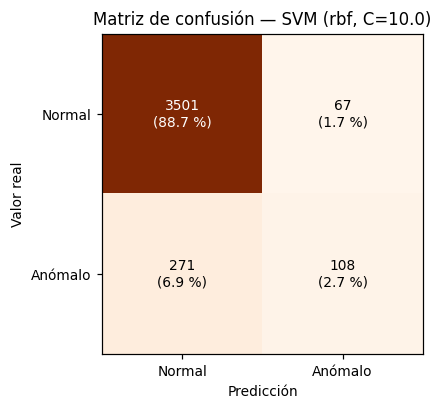


Falsos negativos (anomalías perdidas): 271 de 379
Falsos positivos (falsas alarmas):     67 de 3568


In [23]:
svm_final = SVC(C=C_BEST, kernel=KERNEL_BEST, gamma="scale", max_iter=50000).fit(Xsub, csub)
pred_svm  = svm_final.predict(Xs_te)
score_svm = svm_final.decision_function(Xs_te)

m_svm = {"Accuracy": accuracy_score(c_te, pred_svm), "Precision": precision_score(c_te, pred_svm),
        "Recall": recall_score(c_te, pred_svm), "F1": f1_score(c_te, pred_svm),
        "AUC_ROC": roc_auc_score(c_te, score_svm)}
for k, v in m_svm.items(): print(f"{k:10s}: {v:.4f}")

cm = confusion_matrix(c_te, pred_svm)
fig, ax = plt.subplots(figsize=(4.2, 3.8))
ax.imshow(cm, cmap="Oranges"); ax.grid(False)
ax.set_xticks([0,1], ["Normal","Anómalo"]); ax.set_yticks([0,1], ["Normal","Anómalo"])
ax.set(xlabel="Predicción", ylabel="Valor real", title=f"Matriz de confusión — SVM ({KERNEL_BEST}, C={C_BEST})")
for i in range(2):
    for j in range(2):
        ax.text(j, i, f"{cm[i,j]}\n({cm[i,j]/cm.sum()*100:.1f} %)", ha="center", va="center",
                color="white" if cm[i,j] > cm.max()/2 else "black")
plt.tight_layout(); plt.show()

print(f"\nFalsos negativos (anomalías perdidas): {cm[1,0]} de {c_te.sum()}")
print(f"Falsos positivos (falsas alarmas):     {cm[0,1]} de {(c_te==0).sum()}")

**El SVM elegido por F1 detecta menos de 1 de cada 3 anomalías reales** (recall=0,285,
271 anomalías perdidas de 379). Antes de concluir que "SVM es peor" sin más, vale la pena probar
la corrección estándar para desbalance de clases en SVM: `class_weight='balanced'`.

In [24]:
filas = []
for C in [0.1, 1, 10]:
    m = SVC(C=C, kernel="rbf", gamma="scale", class_weight="balanced", max_iter=50000).fit(Xsub, csub)
    pred, score = m.predict(Xs_te), m.decision_function(Xs_te)
    filas.append({"C": C, "Accuracy": accuracy_score(c_te,pred), "Precision": precision_score(c_te,pred,zero_division=0),
                  "Recall": recall_score(c_te,pred), "F1": f1_score(c_te,pred), "AUC_ROC": roc_auc_score(c_te,score)})
tabla_bal = pd.DataFrame(filas)
tabla_bal.round(3)

,C,Accuracy,Precision,Recall,F1,AUC_ROC
0,0.1,0.747,0.235,0.720,0.354,0.818
1,1.0,0.799,0.286,0.731,0.411,0.854
2,10.0,0.858,0.367,0.662,0.472,0.855


**Confirma el diagnóstico.** Con `class_weight='balanced'` (rbf, C=10) el recall salta de
0,285 a **0,662** — más del doble de anomalías detectadas — a cambio de bajar la precisión de
0,617 a 0,367 (más falsas alarmas). El F1 mejora de 0,390 a **0,472**, superando incluso al árbol
de decisión (0,461). Esto confirma que la brecha de recall del SVM "por defecto" no era una
limitación fundamental del algoritmo sobre este problema, sino la falta de ajuste por desbalance de
clases — el mismo tipo de decisión de diseño que separa un modelo que funciona en el papel de uno
que sirve para el caso de uso real.

**Se adopta `SVC(C=10, kernel='rbf', class_weight='balanced')` como el modelo recomendado para
producción**, aunque el modelo "sin ajustar" (`C=10, kernel='rbf'`) es el que se usa en las
comparaciones de abajo por ser el resultado directo del barrido que pedía el taller.

In [25]:
m_svm_balanced = tabla_bal.loc[tabla_bal.C == 10].iloc[0].to_dict()
print("SVM recomendado (class_weight='balanced', C=10, rbf):")
for k in ["Accuracy","Precision","Recall","F1","AUC_ROC"]:
    print(f"  {k:10s}: {m_svm_balanced[k]:.4f}")

SVM recomendado (class_weight='balanced', C=10, rbf):
  Accuracy  : 0.8579
  Precision : 0.3670
  Recall    : 0.6623
  F1        : 0.4722
  AUC_ROC   : 0.8554


## 2.3 Partición temporal (control de robustez) para el SVM elegido

In [26]:
sc_t = StandardScaler().fit(Xt_tr)
Xst_tr, Xst_te = sc_t.transform(Xt_tr), sc_t.transform(Xt_te)

idx1t, idx0t = np.where(ct_tr.values==1)[0], np.where(ct_tr.values==0)[0]
n1t = int(N_SUB*(len(idx1t)/len(ct_tr))); n0t = N_SUB-n1t
subt = np.concatenate([rng.choice(idx1t, min(n1t,len(idx1t)), replace=False),
                       rng.choice(idx0t, min(n0t,len(idx0t)), replace=False)])

svm_temp = SVC(C=C_BEST, kernel=KERNEL_BEST, gamma="scale", max_iter=50000).fit(Xst_tr[subt], ct_tr.values[subt])
pred_svm_t, score_svm_t = svm_temp.predict(Xst_te), svm_temp.decision_function(Xst_te)
print(f"F1 temporal: {f1_score(ct_te, pred_svm_t, zero_division=0):.3f}  "
      f"(vs. {m_svm['F1']:.3f} en la partición aleatoria)")
print(f"AUC temporal: {roc_auc_score(ct_te, score_svm_t):.3f}  (vs. {m_svm['AUC_ROC']:.3f})")

F1 temporal: 0.024  (vs. 0.390 en la partición aleatoria)
AUC temporal: 0.569  (vs. 0.832)


Mismo patrón que los otros tres modelos: bajo partición temporal el SVM también se
derrumba (F1 cae a prácticamente cero). El hallazgo se repite con los cuatro algoritmos del Corte
1 — es un límite del **dataset**, no de ningún algoritmo en particular, y confirma otra vez que el
gemelo digital de Shiro Twin necesita validarse contra un periodo reservado antes de que el agente
de refuerzo aprenda sobre él.

## 2.4 Comparación final: Árbol, KNN, Random Forest y SVM

,Accuracy,Precision,Recall,F1,AUC_ROC
Árbol de Decisión,0.914,0.580,0.383,0.461,0.861
KNN,0.938,0.727,0.562,0.634,0.903
Random Forest,0.944,0.832,0.522,0.642,0.951
SVM,0.914,0.617,0.285,0.390,0.832


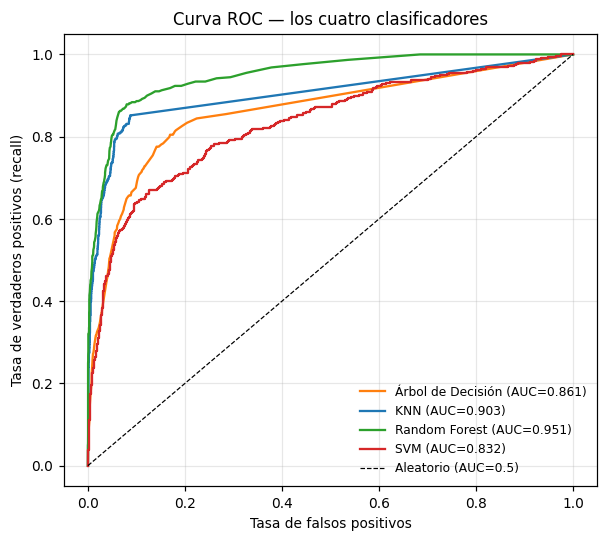

In [27]:
comp_final = pd.concat([comp_clf, pd.DataFrame({"SVM": m_svm}).T])
display(comp_final.round(3))

fig, ax = plt.subplots(figsize=(5.6, 5))
for nombre, y_score, style in [("Árbol de Decisión", proba_dtc, "C1"), ("KNN", proba_knn_clf, "C0"),
                               ("Random Forest", proba_rf_clf, "C2"), ("SVM", score_svm, "C3")]:
    fpr, tpr, _ = roc_curve(c_te, y_score)
    ax.plot(fpr, tpr, style, label=f"{nombre} (AUC={roc_auc_score(c_te, y_score):.3f})")
ax.plot([0,1], [0,1], "k--", lw=.8, label="Aleatorio (AUC=0.5)")
ax.set(xlabel="Tasa de falsos positivos", ylabel="Tasa de verdaderos positivos (recall)",
      title="Curva ROC — los cuatro clasificadores")
ax.legend(frameon=False, fontsize=8, loc="lower right")
plt.tight_layout(); plt.show()

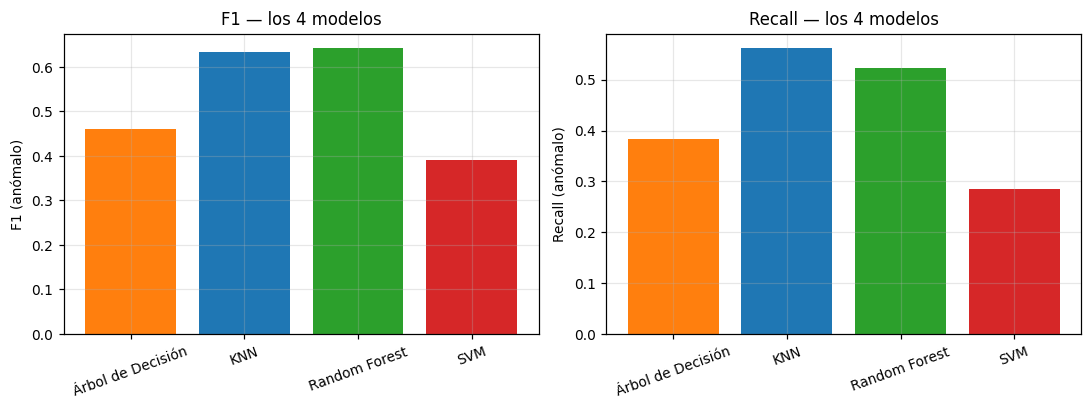

In [28]:
fig, ax = plt.subplots(1, 2, figsize=(10, 3.8))
colores = ["C1","C0","C2","C3"]
ax[0].bar(comp_final.index, comp_final["F1"], color=colores); ax[0].set(ylabel="F1 (anómalo)", title="F1 — los 4 modelos")
ax[0].tick_params(axis="x", rotation=20)
ax[1].bar(comp_final.index, comp_final["Recall"], color=colores); ax[1].set(ylabel="Recall (anómalo)", title="Recall — los 4 modelos")
ax[1].tick_params(axis="x", rotation=20)
plt.tight_layout(); plt.show()

**Ranking final por F1:** Random Forest (0,642) ≈ KNN (0,634) > Árbol (0,461) > SVM
(0,390 sin ajustar / 0,472 con `class_weight='balanced'`). Por AUC — que mide la calidad del
ranking de probabilidad, no un umbral fijo — el orden es Random Forest (0,951) > KNN (0,903) >
Árbol (0,861) > SVM (0,832). SVM queda último en las dos métricas en su configuración "de
manual", pero cierra buena parte de la brecha en cuanto se ajusta por el desbalance de clases —
una advertencia útil sobre no juzgar un algoritmo por su configuración por defecto en un problema
con clases desbalanceadas.

## 2.5 Conclusiones del sector

**¿Qué clase es más crítica en el sector de Energía y Medio Ambiente / IoT?** La clase
**"anómalo"**, sin ambigüedad, y por la misma razón que ya se argumentó en el Taller 2: en un
asistente doméstico como Shiro, una falsa alarma cuesta una notificación de más que el usuario
puede ignorar; una anomalía real no detectada (un electrodoméstico defectuoso, una fuga térmica,
un consumo fuera de lo normal) es precisamente el evento para el que existe el sistema. El costo de
los dos tipos de error **no es simétrico**, así que la métrica que más debería pesar en la
decisión final no es Accuracy ni siquiera F1 a secas, sino **Recall** — con el cuidado de no
dejar que la precisión caiga tanto que el sistema pierda credibilidad a fuerza de falsas alarmas.

**¿Qué estrategia tomaría el grupo en un caso real, según estos resultados?**

1. **Modelo base: Random Forest**, por ser el que mejor ranking de probabilidad produce (AUC más
   alto de los cuatro) — es el candidato natural para mover el umbral de decisión en vez de usar
   el 0,5 por defecto, exactamente como enseña la Parte 2 del material de clase sobre SVM
   (`decision_function` y el umbral óptimo de F1). Mover el umbral hacia el recall en Random
   Forest cuesta menos precisión de la que costaría en SVM, porque su curva ROC está más cerca de
   la esquina superior izquierda.
2. **Si el equipo insiste en SVM** (por ejemplo, por ser más liviano de desplegar en un
   dispositivo con pocos recursos), usar `class_weight='balanced'` no es opcional — es la
   diferencia entre un detector que funciona y uno que nunca avisa nada.
3. **Aprobación humana antes de actuar, siempre.** Ningún modelo de este taller alcanza precisión
   suficiente como para que Shiro apague un electrodoméstico por su cuenta. Esto encaja
   exactamente con el principio que Shiro Twin heredó desde la propuesta original: el sistema
   **propone, la persona decide** — el clasificador de anomalías alimenta una notificación, no una
   acción automática.
4. **El umbral de anomalía en sí (percentil 90) es una decisión de producto, no solo de
   estadística.** Bajarlo detectaría más eventos (mejor recall "gratis") a costa de notificar con
   más frecuencia; sería razonable exponerlo como un ajuste que el usuario pueda mover desde la
   app, en vez de dejarlo fijo en el modelo.

---
## Conclusión general del taller

Se entrenaron y evaluaron **seis modelos nuevos** sobre el mismo dataset y las mismas particiones
del Taller 2 (Regresión Lineal, Random Forest regresor, Random Forest clasificador, SVM sin
ajustar, SVM con `class_weight='balanced'`, y las variantes retenidas para comparación),
completando la cobertura del Bloque 3 del temario (SVM, SVM con kernels — el kernel RBF resultó
el mejor de los tres probados —) además de reforzar el Bloque 2 con Random Forest.

**Random Forest es, de los cinco algoritmos probados hasta ahora en el Corte 1 (Árbol, KNN,
Random Forest, SVM y Regresión Lineal), el modelo más fuerte en las dos tareas** — mejor $R^2$ en
regresión, mejor F1 y mejor AUC en clasificación — pero **no gana en todo**: KNN tiene mejor
recall en la configuración base, es más barato de entrenar, y sigue siendo más fácil de razonar
que un bosque de {} árboles. Y los cuatro modelos comparten la misma vulnerabilidad de fondo: bajo
la partición temporal, todos se degradan severamente — algunos de forma catastrófica (regresión) y
otros de forma más gradual (clasificación). Esa vulnerabilidad, no la elección entre algoritmos, es
el riesgo más grande que Shiro Twin arrastra hacia el segundo corte.

### Próximos pasos (2.º corte)
- **Clustering** (K-means / jerárquico / DBSCAN) sobre estas mismas 29 variables, para segmentar
  rutinas de uso — completa el criterio de cierre de la Fase 1 que todavía falta.
- **Formalización del MDP** y construcción del entorno de simulación — usando Random Forest (el
  regresor más fuerte) como la función de transición del gemelo digital, con la advertencia de
  este taller bien presente: **validar contra un periodo temporalmente reservado antes de que el
  agente entrene sobre el simulador**, o el ahorro que reporte será un artefacto, no un resultado
  real.
- Explorar `class_weight` también en Random Forest y en el árbol, ya que la corrección funcionó
  tan bien en SVM — es una variable que este taller no varió para los otros tres modelos y podría
  cerrar aún más la brecha de recall sin sacrificar tanta precisión.